In [1]:
import pandas as pd

In [2]:
data=pd.read_csv('Titanic-Dataset.csv')

In [3]:
data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
print(data.shape)

(891, 12)


In [5]:
data.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

In [6]:
missing_values = data.isnull().sum()
print("Missing values per column:")
print(missing_values)

Missing values per column:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [7]:
if 'Age' in data.columns:
    data['Age'] = data['Age'].fillna(data['Age'].median())


In [8]:
data.Age

0      22.0
1      38.0
2      26.0
3      35.0
4      35.0
       ... 
886    27.0
887    19.0
888    28.0
889    26.0
890    32.0
Name: Age, Length: 891, dtype: float64

In [9]:
data.drop(columns=['Cabin'],inplace=True)

In [10]:
data.Cabin

AttributeError: 'DataFrame' object has no attribute 'Cabin'

In [11]:
if 'Embarked' in data.columns:
    data['Embarked']=data['Embarked'].fillna(data['Embarked'].mode()[0])

In [12]:
data.Embarked

0      S
1      C
2      S
3      S
4      S
      ..
886    S
887    S
888    S
889    C
890    Q
Name: Embarked, Length: 891, dtype: object

In [13]:
passengers=data[(data['Sex']=='male') & (data['Age']>30)]
print(passengers[['Name', 'Age', 'Sex']])


                                     Name   Age   Sex
4                Allen, Mr. William Henry  35.0  male
6                 McCarthy, Mr. Timothy J  54.0  male
13            Andersson, Mr. Anders Johan  39.0  male
20                   Fynney, Mr. Joseph J  35.0  male
21                  Beesley, Mr. Lawrence  34.0  male
..                                    ...   ...   ...
867  Roebling, Mr. Washington Augustus II  31.0  male
872              Carlsson, Mr. Frans Olof  33.0  male
873           Vander Cruyssen, Mr. Victor  47.0  male
881                    Markun, Mr. Johann  33.0  male
890                   Dooley, Mr. Patrick  32.0  male

[202 rows x 3 columns]


In [14]:
survived=data[data['Survived']>0]
print(survived[['Name','Age','Fare']])

                                                  Name   Age     Fare
1    Cumings, Mrs. John Bradley (Florence Briggs Th...  38.0  71.2833
2                               Heikkinen, Miss. Laina  26.0   7.9250
3         Futrelle, Mrs. Jacques Heath (Lily May Peel)  35.0  53.1000
8    Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)  27.0  11.1333
9                  Nasser, Mrs. Nicholas (Adele Achem)  14.0  30.0708
..                                                 ...   ...      ...
875                   Najib, Miss. Adele Kiamie "Jane"  15.0   7.2250
879      Potter, Mrs. Thomas Jr (Lily Alexenia Wilson)  56.0  83.1583
880       Shelley, Mrs. William (Imanita Parrish Hall)  25.0  26.0000
887                       Graham, Miss. Margaret Edith  19.0  30.0000
889                              Behr, Mr. Karl Howell  26.0  30.0000

[342 rows x 3 columns]


In [15]:
Pasengers=data[data['Fare']>100]
print(" passengers who paid a fare greater than 100:",Pasengers[['Name','Fare']])

 passengers who paid a fare greater than 100:                                                   Name      Fare
27                      Fortune, Mr. Charles Alexander  263.0000
31      Spencer, Mrs. William Augustus (Marie Eugenie)  146.5208
88                          Fortune, Miss. Mabel Helen  263.0000
118                           Baxter, Mr. Quigg Edmond  247.5208
195                               Lurette, Miss. Elise  146.5208
215                            Newell, Miss. Madeleine  113.2750
258                                   Ward, Miss. Anna  512.3292
268      Graham, Mrs. William Thompson (Edith Junkins)  153.4625
269                             Bissette, Miss. Amelia  135.6333
297                       Allison, Miss. Helen Loraine  151.5500
299    Baxter, Mrs. James (Helene DeLaudeniere Chaput)  247.5208
305                     Allison, Master. Hudson Trevor  151.5500
306                            Fleming, Miss. Margaret  110.8833
307  Penasco y Castellana, Mrs. Victor de Sa

In [16]:
avg_fare=data.groupby('Pclass')['Fare'].mean()
print(avg_fare)

Pclass
1    84.154687
2    20.662183
3    13.675550
Name: Fare, dtype: float64


In [17]:
embarkation_counts = data['Embarked'].value_counts()
print(embarkation_counts)

Embarked
S    646
C    168
Q     77
Name: count, dtype: int64


In [18]:
grouped=data.groupby('Sex')['Age'].max()
print(grouped)

Sex
female    63.0
male      80.0
Name: Age, dtype: float64


In [19]:
sort_data=data.sort_values(by='Age',ascending=False)
print(sort_data[['Age','Name']])

       Age                                  Name
630  80.00  Barkworth, Mr. Algernon Henry Wilson
851  74.00                   Svensson, Mr. Johan
96   71.00             Goldschmidt, Mr. George B
493  71.00               Artagaveytia, Mr. Ramon
116  70.50                  Connors, Mr. Patrick
..     ...                                   ...
831   0.83       Richards, Master. George Sibley
644   0.75                Baclini, Miss. Eugenie
469   0.75         Baclini, Miss. Helene Barbara
755   0.67             Hamalainen, Master. Viljo
803   0.42       Thomas, Master. Assad Alexander

[891 rows x 2 columns]


In [20]:
# Sort by Fare in descending order
sort_by_fare = data.sort_values(by='Fare', ascending=False)
print("Sorted by Fare (High to Low):")
print(sort_by_fare[['Fare', 'Age', 'Name']])

# Sort by Age in ascending order
sort_by_age = data.sort_values(by='Age', ascending=True)
print("\nSorted by Age (Youngest to Oldest):")
print(sort_by_age[['Fare', 'Age', 'Name']])


Sorted by Fare (High to Low):
         Fare   Age                                Name
679  512.3292  36.0  Cardeza, Mr. Thomas Drake Martinez
258  512.3292  35.0                    Ward, Miss. Anna
737  512.3292  35.0              Lesurer, Mr. Gustave J
88   263.0000  23.0          Fortune, Miss. Mabel Helen
438  263.0000  64.0                   Fortune, Mr. Mark
..        ...   ...                                 ...
806    0.0000  39.0              Andrews, Mr. Thomas Jr
815    0.0000  28.0                    Fry, Mr. Richard
466    0.0000  28.0               Campbell, Mr. William
481    0.0000  28.0    Frost, Mr. Anthony Wood "Archie"
822    0.0000  38.0     Reuchlin, Jonkheer. John George

[891 rows x 3 columns]

Sorted by Age (Youngest to Oldest):
        Fare    Age                                  Name
803   8.5167   0.42       Thomas, Master. Assad Alexander
755  14.5000   0.67             Hamalainen, Master. Viljo
469  19.2583   0.75         Baclini, Miss. Helene Barbara
644  

In [21]:
!pip install matplotlib


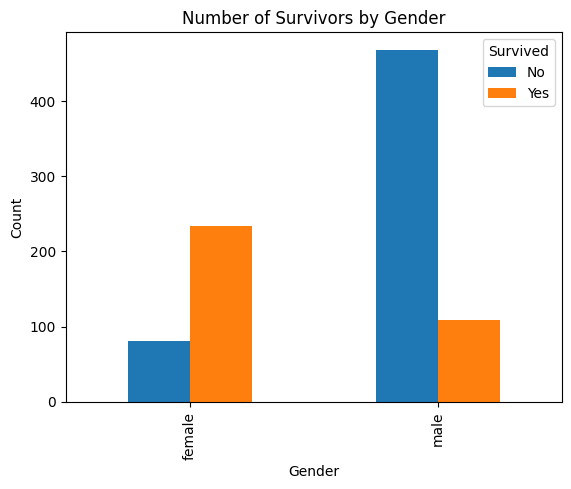

In [22]:
import pandas as pd
import matplotlib.pyplot as plt

# Group by 'Sex' and 'Survived', then count
gender_survival = data.groupby(['Sex', 'Survived']).size().unstack()

# Plot
gender_survival.plot(kind='bar', stacked=False)
plt.title('Number of Survivors by Gender')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.legend(title='Survived', labels=['No', 'Yes'])
plt.show()


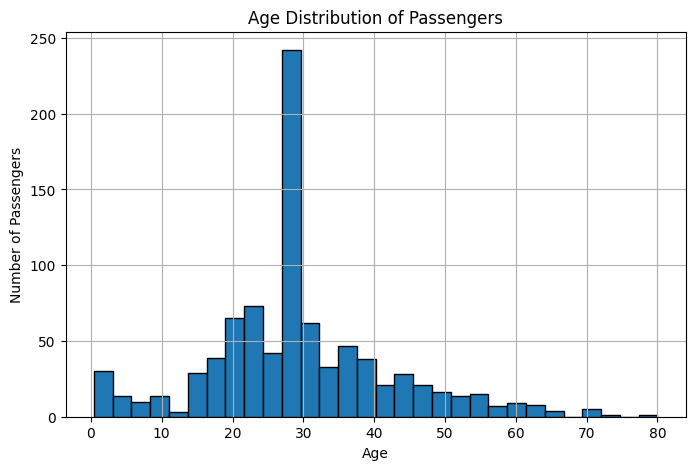

In [23]:
data['Age'].plot(kind='hist', bins=30, edgecolor='black', figsize=(8,5))
plt.title('Age Distribution of Passengers')
plt.xlabel('Age')
plt.ylabel('Number of Passengers')
plt.grid(True)
plt.show()


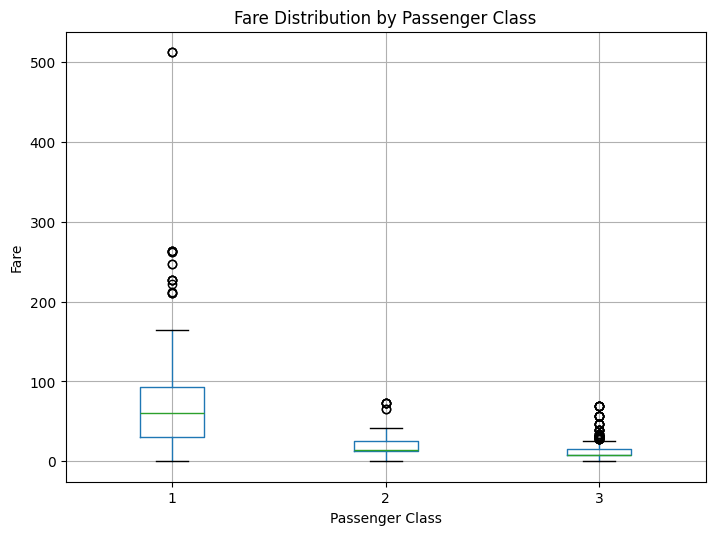

In [24]:
data.boxplot(column='Fare', by='Pclass', figsize=(8,6))
plt.title('Fare Distribution by Passenger Class')
plt.suptitle('')  # Removes automatic subtitle
plt.xlabel('Passenger Class')
plt.ylabel('Fare')
plt.show()
